# Asteroid classificarion with Machine Learning

### Machine Learning Classification Project

**Author:** Juan Manuel Candela | **Date:** april 2026  
**Dataset:** NASA: Asteroids Classification 

**Source:** Kaggle – NASA: Asteroids Classification  
https://www.kaggle.com/datasets/lovishbansal123/nasa-asteroids-classification/data

---

## 1. Project Overview

This project analyzes physical and orbital features of near Earth asteroids from NASA's dataset to predict whether an asteroid is potentially hazardous.

The goal is to biuld and compare multiple machine learning models as regression and classification to determinate wich model predicts asteroid hazard status.

---

## 2. Dataset Features

- **id** - Unique asteroid identifier 
- **name** - Asteoid name
- **Absolute magnitude** - intrinsic brightness of the asteoid
- **Estimated diameter** - Range of estimated size (min-max across units)
- **Close approach date** - Date of closest approach to earth
- **Epoch date close approach** - Timestamp of the close approach
- **Orbiting body** - Celestial body the asteroid orbits
- **Orbit id** - Identifier to the orbital solution
- **Relative velocity** - Speed of the asteroid relative to earth
- **Miss distance** - Closest distance to earth
- **Hazardous** - Indicates whether the asteroid is potentially dangerous
---

## 3. Project Includes

- Reading and exploring CSV data  
- Data inspection and preprocessing  
- Checking for missing values
- Removing redundant features
- One-hot encoding for categorical variables  
- Train–test split for model validation  
- Feature scaling using **StandardScaler**  
- Implementation of **Linear Regression**  
- Implementation of **Decision tree**  
- Implementation of **Random forest**  
- Implementation of **Logistic regression**
- Implementation of **K-Nearest Neighbors**    
- Implementation of **Support vector machines** 
- Model evaluation using **MSE, R² and F1-score**  
- Model comparison

## Libraries

In [374]:
# Data manipulation
import pandas as pd
import numpy as np

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer, make_column_selector

# Regression model
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Clasification model
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn import svm

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Preprocessing data

#### 1.1 Data import

In [375]:
df = pd.read_csv("nasa.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4687 entries, 0 to 4686
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Neo Reference ID              4687 non-null   int64  
 1   Name                          4687 non-null   int64  
 2   Absolute Magnitude            4687 non-null   float64
 3   Est Dia in KM(min)            4687 non-null   float64
 4   Est Dia in KM(max)            4687 non-null   float64
 5   Est Dia in M(min)             4687 non-null   float64
 6   Est Dia in M(max)             4687 non-null   float64
 7   Est Dia in Miles(min)         4687 non-null   float64
 8   Est Dia in Miles(max)         4687 non-null   float64
 9   Est Dia in Feet(min)          4687 non-null   float64
 10  Est Dia in Feet(max)          4687 non-null   float64
 11  Close Approach Date           4687 non-null   object 
 12  Epoch Date Close Approach     4687 non-null   int64  
 13  Rel

,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Semi Major Axis,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion
count,4.687000e+03,4.687000e+03,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,...,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,4.687000e+03,4687.000000,4687.000000
mean,3.272298e+06,3.272298e+06,22.267865,0.204604,0.457509,204.604203,457.508906,0.127135,0.284283,671.273653,...,1.400264,13.373844,172.157275,635.582076,0.813383,183.932151,1.987144,2.457728e+06,181.167927,0.738242
std,5.486011e+05,5.486011e+05,2.890972,0.369573,0.826391,369.573402,826.391249,0.229642,0.513496,1212.511199,...,0.524154,10.936227,103.276777,370.954727,0.242059,103.513035,0.951519,9.442264e+02,107.501623,0.342627
min,2.000433e+06,2.000433e+06,11.160000,0.001011,0.002260,1.010543,2.259644,0.000628,0.001404,3.315431,...,0.615920,0.014513,0.001941,176.557161,0.080744,0.006918,0.803765,2.450100e+06,0.003191,0.086285
25%,3.097594e+06,3.097594e+06,20.100000,0.033462,0.074824,33.462237,74.823838,0.020792,0.046493,109.784247,...,1.000635,4.962341,83.081208,365.605031,0.630834,95.625916,1.266059,2.457815e+06,87.006918,0.453289
50%,3.514799e+06,3.514799e+06,21.900000,0.110804,0.247765,110.803882,247.765013,0.068850,0.153954,363.529809,...,1.240981,10.311836,172.625393,504.947292,0.833153,189.761641,1.618195,2.457973e+06,185.718889,0.712946
75%,3.690060e+06,3.690060e+06,24.500000,0.253837,0.567597,253.837029,567.596853,0.157727,0.352688,832.798679,...,1.678364,19.511681,255.026909,794.195972,0.997227,271.777557,2.451171,2.458108e+06,276.531946,0.984669
max,3.781897e+06,3.781897e+06,32.100000,15.579552,34.836938,15579.552413,34836.938254,9.680682,21.646663,51114.018738,...,5.072008,75.406667,359.905890,4172.231343,1.299832,359.993098,8.983852,2.458839e+06,359.917991,2.039000


#### 1.2 Selection and transformation
In this dataset we have just this 6 useful features:

In [376]:
dataframe = df[[
    'Absolute Magnitude',
    'Est Dia in KM(min)',
    'Est Dia in KM(max)',
    'Miss Dist.(kilometers)',
    'Relative Velocity km per sec',
    'Hazardous'
    ]]

print(dataframe.info())
print(dataframe.head())
print(dataframe.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4687 entries, 0 to 4686
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Absolute Magnitude            4687 non-null   float64
 1   Est Dia in KM(min)            4687 non-null   float64
 2   Est Dia in KM(max)            4687 non-null   float64
 3   Miss Dist.(kilometers)        4687 non-null   float64
 4   Relative Velocity km per sec  4687 non-null   float64
 5   Hazardous                     4687 non-null   bool   
dtypes: bool(1), float64(5)
memory usage: 187.8 KB
None
   Absolute Magnitude  Est Dia in KM(min)  Est Dia in KM(max)  \
0                21.6            0.127220            0.284472   
1                21.3            0.146068            0.326618   
2                20.3            0.231502            0.517654   
3                27.4            0.008801            0.019681   
4                21.6            0.127220

#### 1.3 Data splitting

In [377]:
# Target
y = dataframe["Relative Velocity km per sec"]

# df procesed
X = dataframe.drop(["Relative Velocity km per sec"], axis=1)

# Data split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [378]:
print(y)

0        6.115834
1       18.113985
2        7.590711
3       11.173874
4        9.840831
          ...    
4682    22.154265
4683     3.225150
4684     7.191642
4685    11.352090
4686    35.946852
Name: Relative Velocity km per sec, Length: 4687, dtype: float64


In [379]:
print(X_train)

      Absolute Magnitude  Est Dia in KM(min)  Est Dia in KM(max)  \
1436                24.2            0.038420            0.085909   
3568                22.6            0.080270            0.179490   
3624                26.8            0.011603            0.025944   
1374                23.3            0.058151            0.130029   
2659                21.0            0.167708            0.375008   
...                  ...                 ...                 ...   
4426                25.2            0.024241            0.054205   
466                 25.4            0.022108            0.049436   
3092                21.2            0.152952            0.342011   
3772                26.2            0.015295            0.034201   
860                 19.2            0.384198            0.859093   

      Miss Dist.(kilometers)  Hazardous  
1436             51582424.00      False  
3568             72585976.00      False  
3624              1844860.75      False  
1374           

In [380]:
print(X_test.info())

<class 'pandas.core.frame.DataFrame'>
Index: 938 entries, 3804 to 2607
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Absolute Magnitude      938 non-null    float64
 1   Est Dia in KM(min)      938 non-null    float64
 2   Est Dia in KM(max)      938 non-null    float64
 3   Miss Dist.(kilometers)  938 non-null    float64
 4   Hazardous               938 non-null    bool   
dtypes: bool(1), float64(4)
memory usage: 37.6 KB
None


#### 1.4 Data scaling

In [381]:
sc = StandardScaler()

num_cols = X_train.select_dtypes(include=["number"]).columns

X_train[num_cols] = sc.fit_transform(X_train[num_cols])
X_test[num_cols] = sc.transform(X_test[num_cols])

print(X_test.describe())

       Absolute Magnitude  Est Dia in KM(min)  Est Dia in KM(max)  \
count          938.000000          938.000000          938.000000   
mean            -0.028369            0.041007            0.041007   
std              1.038570            0.914748            0.914748   
min             -2.916036           -0.528259           -0.528259   
25%             -0.796335           -0.447316           -0.447316   
50%             -0.168792           -0.227559           -0.227559   
75%              0.772523            0.171089            0.171089   
max              2.585426           11.097072           11.097072   

       Miss Dist.(kilometers)  
count              938.000000  
mean                 0.024633  
std                  1.009428  
min                 -1.758113  
25%                 -0.837728  
50%                  0.094083  
75%                  0.922529  
max                  1.673286  


## 2. Regression

In [382]:
# Linear regression model
def linear_regression(X_train, X_test, y_train, y_test):
    lr = LinearRegression()

    lr.fit(X_train, y_train)

    # Prediction
    y_pred_mlr = lr.predict(X_test)

    # Metrics

    # mean squared error
    mse = mean_squared_error(y_test, y_pred_mlr)

    # R2 score
    r2 = r2_score(y_test, y_pred_mlr)
    
    # Correlation matrix
    correlation = X_train.corr()
    
    return mse, r2, y_pred_mlr, lr, correlation

# Unpack MLR
mse_mlr, r2_mlr, y_pred_mlr, lr, correlation = linear_regression(X_train, X_test, y_train, y_test)

### Correlation matrix

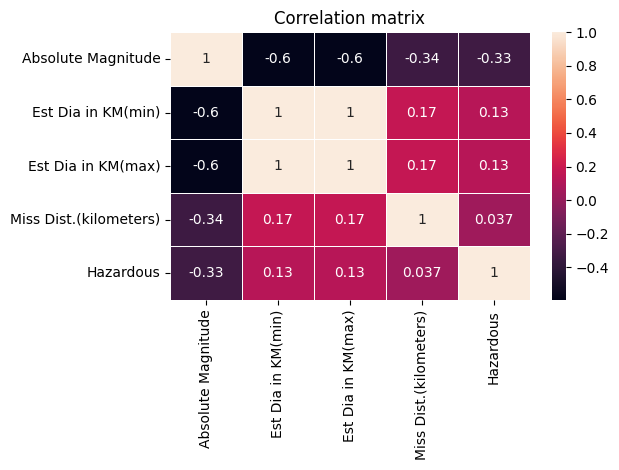

In [383]:
fig, ax = plt.subplots()
sns.heatmap(
    correlation,
    annot=True,
    lw=0.5,
)

ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show() 

In [384]:
print(f"Linear regression RMSE: {np.sqrt(mse_mlr):.2f}")
print(f"Linear regression MSE: {mse_mlr:.2f}")
print(f"Linear regression R²: {r2_mlr:.2f}")

Linear regression RMSE: 6.60
Linear regression MSE: 43.55
Linear regression R²: 0.24


## 2.2 Decision tree

In [385]:
def decision_tree(X_train, X_test, y_train, y_test):
    regressor = DecisionTreeRegressor(random_state=42)

    regressor.fit(X_train, y_train)

    decision_tree_pred = regressor.predict(X_test)

    # mean squared error
    mse_dt = mean_squared_error(y_test, decision_tree_pred)

    # R2 score
    r2_dt = r2_score(y_test, decision_tree_pred)
    
    return decision_tree_pred, mse_dt, r2_dt

decision_tree_pred, mse_dt, r2_dt = decision_tree(X_train, X_test, y_train, y_test)


In [386]:
print(f"Decision tree RMSE: {np.sqrt(mse_dt):.2f}")
print(f"Decision tree MSE: {mse_dt:.2f}")
print(f"Decision tree R²: {r2_dt:.2f}")

Decision tree RMSE: 9.03
Decision tree MSE: 81.56
Decision tree R²: -0.43


## 2.3 Random Forest

In [387]:
def random_forest(X_train, X_test, y_train, y_test):
    
    rfr = RandomForestRegressor(max_depth=2, random_state=0)
    
    rfr.fit(X_train, y_train)
    
    random_forest_pred = rfr.predict(X_test)
    
    rf_mse = mean_squared_error(y_test, random_forest_pred)
    
    rf_r2 = r2_score(y_test, random_forest_pred)
    
    return random_forest_pred, rf_mse, rf_r2

random_forest_pred, rf_mse, rf_r2 = random_forest(X_train, X_test, y_train, y_test)
    
    

In [388]:
print(f"Random Forest RMSE: {np.sqrt(rf_mse):.2f}")
print(f"Random Forest MSE: {(rf_mse):.2f}")
print(f"Random Forest R²: {(rf_r2):.2f}")

Random Forest RMSE: 6.63
Random Forest MSE: 43.99
Random Forest R²: 0.23


In [389]:
metrics = {
    "Linear Regression": {"MSE": mse_mlr, "R2": r2_mlr},
    "Decision Tree":     {"MSE": mse_dt, "R2": r2_dt},
    "Random Forest":     {"MSE": rf_mse, "R2": rf_r2}
}

tabla = pd.DataFrame(metrics).T.round(4)
print(tabla)

                       MSE      R2
Linear Regression  43.5514  0.2369
Decision Tree      81.5589 -0.4291
Random Forest      43.9927  0.2291


## 3. Classification

#### 3.1 Logistic regression

In [390]:
dataframe_classif = df[[
    'Absolute Magnitude',
    'Est Dia in KM(min)',
    'Est Dia in KM(max)',
    'Miss Dist.(kilometers)',
    'Relative Velocity km per sec',
    'Hazardous'
    ]]

# Target
y_classif = dataframe_classif["Hazardous"]

# Features
X_classif = dataframe_classif.drop(["Hazardous"], axis=1)

# Data split (80/20)
X_train_classif, X_test_classif, y_train_classif, y_test_classif = train_test_split(X_classif, y_classif, test_size=0.2, random_state=42)

# Scaling

sc_classif = StandardScaler()

num_cols_classif = X_train_classif.select_dtypes(include=["number"]).columns

X_train_classif[num_cols_classif] = sc_classif.fit_transform(X_train_classif[num_cols_classif])
X_test_classif[num_cols_classif] = sc_classif.transform(X_test_classif[num_cols_classif])


In [391]:
def LogRegression(X_train_classif, X_test_classif, y_train_classif, y_test_classif):
    
    lr = LogisticRegression(random_state=42)
    
    lr.fit(X_train_classif, y_train_classif)
    
    log_reg_predict = lr.predict(X_test_classif)
    
    # accuracy logistic regression
    accuracy_log_reg = accuracy_score(y_test_classif, log_reg_predict)
    # F1 score
    f1_log_reg = f1_score(y_test_classif, log_reg_predict)
    
    return log_reg_predict, accuracy_log_reg, f1_log_reg

In [392]:
log_reg_predict, accuracy_log_reg, f1_log_reg = LogRegression(X_train_classif, X_test_classif, y_train_classif, y_test_classif)

In [393]:
print(f"Logistic regression Accuracy score: {accuracy_log_reg:.4f}")
print(f"Logistic regression F1_score: {f1_log_reg:.4f}")

Logistic regression Accuracy score: 0.8390
Logistic regression F1_score: 0.1170


#### 3.2 K-Nearest Neighbors

3.2.1 Find the best k

In [394]:
# KNN model
neighbors= range(1,25)
def KNN_best_k(X_train_classif, X_test_classif, y_train_classif, y_test_classif):
    training_accuracy = []
    test_accuracy = []
    # Find Best K value in KNN
    for k in neighbors:
        neigh = KNeighborsClassifier(n_neighbors=k)
        neigh.fit(X_train_classif, y_train_classif)
        
        #y_pred_KNN = neigh.predict(X_test)
        
        training_accuracy.append(neigh.score(X_train_classif, y_train_classif))
        test_accuracy.append(neigh.score(X_test_classif, y_test_classif))
        
    #return training_accuracy, test_accuracy
    
    plt.title("KNN accuracy for different K values")
    plt.plot(neighbors, training_accuracy, label="Training accuracy")
    plt.plot(neighbors, test_accuracy, label="Test accuracy")
    plt.xticks(np.arange(1,25,4))
    plt.vlines(6, 0.8, 1, label="Best K", colors="black", linestyles="--")
    plt.ylabel("Accuracy")
    plt.xlabel("K values")
    plt.legend()
    plt.show()

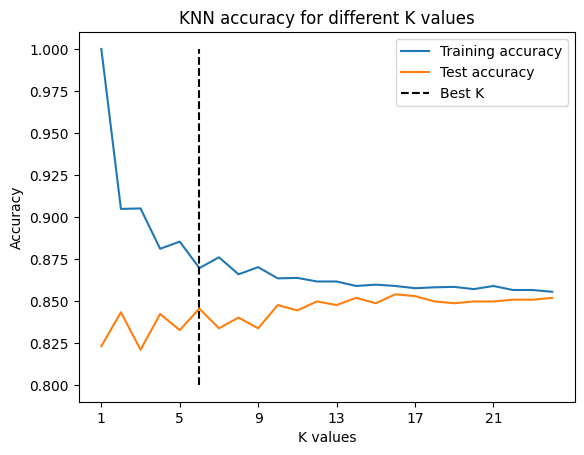

In [395]:
KNN_best_k(X_train_classif, X_test_classif, y_train_classif, y_test_classif)

In [396]:
def KNearestNeighbors(X_train_classif, X_test_classif, y_train_classif, y_test_classif):
    neigh = KNeighborsClassifier(n_neighbors=6)
    
    neigh.fit(X_train_classif, y_train_classif)
    
    knn_pred = neigh.predict(X_test_classif)
    
    # Accuracy score
    
    accuracy_knn = neigh.score(X_test_classif, y_test_classif)
    
    # F1 score
    f1_knn = f1_score(y_test_classif, knn_pred)
    
    return knn_pred, accuracy_knn, f1_knn

knn_pred, accuracy_knn, f1_knn = KNearestNeighbors(X_train_classif, X_test_classif, y_train_classif, y_test_classif)

In [397]:
print(f"K-Nearest Neighbors accuracy: {accuracy_knn:.4f}")
print(f"K-Nearest Neighbors F1_score: {f1_knn:.4f}")

K-Nearest Neighbors accuracy: 0.8454
K-Nearest Neighbors F1_score: 0.2564


#### 3.3 Support Vector Machines

In [398]:
def SupportVectorMachines(X_train_classif, X_test_classif, y_train_classif, y_test_classif):
    # instantiate
    svc = svm.SVC(class_weight='balanced', random_state=42)
    # find best parameters
    parameters = {'kernel':['rbf'],
                  'C':[0.1, 1, 10, 100],
                  "gamma": [0.001, 0.01, 0.1, 1, 'scale']}
    clf = GridSearchCV(svc, parameters)
    # fit
    clf.fit(X_train_classif, y_train_classif)
    # predict
    svm_pred = clf.predict(X_test_classif)
    
    # accuracy
    accuracy_svm = clf.score(X_test_classif, y_test_classif)
    
    # F1 score
    f1_svm = f1_score(y_test_classif, svm_pred)

    # Confusion matrix
    confusion = confusion_matrix(y_test_classif, svm_pred)
    
    return svm_pred, accuracy_svm, f1_svm, confusion

svm_pred, accuracy_svm, f1_svm, confusion = SupportVectorMachines(X_train_classif, X_test_classif, y_train_classif, y_test_classif)    

In [399]:
print(f"Support Vector Machines accuracy: {accuracy_svm:.4f}")
print(f"Support Vector Machines f1_score: {f1_svm:.4f}")

Support Vector Machines accuracy: 0.7004
Support Vector Machines f1_score: 0.4501


### Classification Metrics

In [400]:
metrics = {
    "Logistic Regression": {"Accuracy": accuracy_log_reg, "F1-score": f1_log_reg},
    "K-Nearest Neighbors":     {"Accuracy": accuracy_knn, "F1-score": f1_knn},
    "Support Vector Machines":     {"Accuracy": accuracy_svm, "F1-score": f1_svm}
}

tabla = pd.DataFrame(metrics).T
print(tabla)

                         Accuracy  F1-score
Logistic Regression      0.839019  0.116959
K-Nearest Neighbors      0.845416  0.256410
Support Vector Machines  0.700426  0.450098


Now we pick the SVM which gives us the best accuracy, and we are going to look at the confusion matrix.

Text(0.5, 1.0, 'Confusion matix SVM')

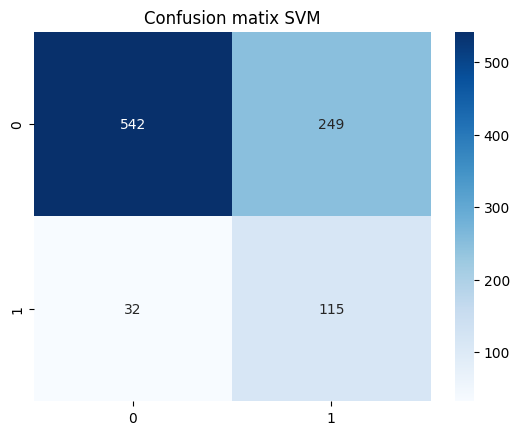

In [401]:
y = sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
y.set_title("Confusion matix SVM")

# Final toughts

- The best way to study this dataset is through **classification models**, since the 
goal is to predict whether an asteroid is potentially hazardous or not.

- We trained three classifiers — Logistic Regression, K-Nearest Neighbors, and 
Support Vector Machine — and the **SVM with RBF kernel** gave the best results.

- One of the most important lessons from this project was the impact of **feature 
scaling**. Without it, the model predicted almost every asteroid as non-hazardous, 
giving a high accuracy (~84%) but missing nearly all the dangerous ones. After 
scaling the features correctly, the model detected 115 out of 147 hazardous 
asteroids, which is a much more useful result.

- The final confusion matrix shows **32 false negatives** and **249 false positives**. 
In this context, that trade-off makes sense — it is better to raise a false alarm 
than to miss a truly dangerous asteroid.

- Overall, this project showed that choosing the right preprocessing steps and 
evaluation metrics matters as much as choosing the right model.